Importing Necessary Dependencies.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

np.random.seed(1)

**Problem 1**

In [3]:
def func_gradient(x):
    return np.array([-2 + 2 * x[0] - (400 * (x[1] - x[0] ** 2) * x[0]), 200 * (x[1] - x[0] ** 2)])

# Since both terms of the function involves squaring, there is no point on the function where f(x_1, x_2) < 0. Therefore, if we look at the pair (1, 1), we get that f(1, 1) = 0, which is the optimal solution.

Gradient Descent Final Value: [0.99888299 0.99776276] over 151234 iterations.


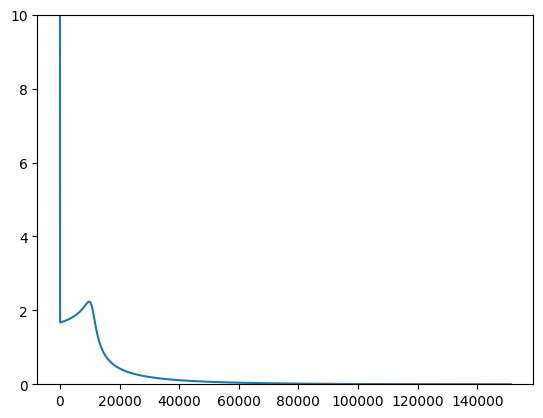

In [4]:
init_x = np.array([-1.5, 1.5])
all_gradient_norms = []
def gradient_descent(X, step_size=0.0001, stop_cond=0.001, max_iterations=1000000):
    iterations = 0
    gradient_norm = []
    for _ in range(max_iterations):
        iterations += 1
        grad = func_gradient(X)
        norm_grad = np.linalg.norm(grad)
        gradient_norm.append(norm_grad)
        if norm_grad < stop_cond:
            return [X, iterations, gradient_norm]
        X = X - step_size * grad
    return [X, iterations, gradient_norm]

grad_desc_vals = gradient_descent(init_x)
all_gradient_norms.append([grad_desc_vals[2], grad_desc_vals[1]])
print("Gradient Descent Final Value:", grad_desc_vals[0], "over", grad_desc_vals[1], "iterations.")
plt.plot([i for i in range(grad_desc_vals[1])], grad_desc_vals[2])
plt.ylim(top=10, bottom=0)
plt.show()

Gradient Descent (Momentum) Final Value: [0.98891882 0.97791579] over 94067 iterations.


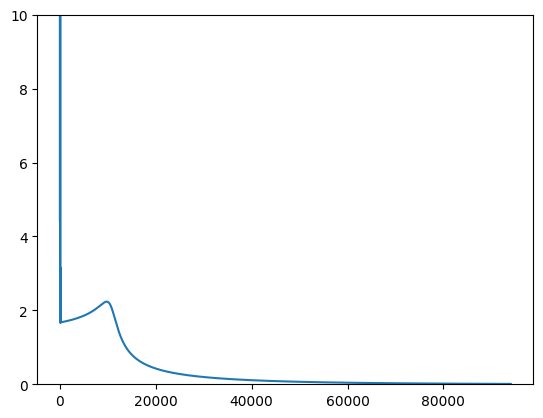

In [5]:
def gradient_descent_mmt(X, beta=0.90, step_size=0.0001, stop_cond=0.01, max_iterations=1000000):
    iterations = 0
    gradient_norm = []
    v = np.array([0, 0])
    for _ in range(max_iterations):
        iterations += 1
        grad = func_gradient(X)
        norm_grad = np.linalg.norm(grad)
        gradient_norm.append(norm_grad)
        if norm_grad < stop_cond:
            return [X, iterations, gradient_norm]
        v = beta * v + (1 - beta) * grad
        X = X - step_size * v
    return [X, iterations, gradient_norm]

grad_desc_mmt_vals = gradient_descent_mmt(init_x)
all_gradient_norms.append([grad_desc_mmt_vals[2], grad_desc_mmt_vals[1]])
print("Gradient Descent (Momentum) Final Value:", grad_desc_mmt_vals[0], "over", grad_desc_mmt_vals[1], "iterations.")
plt.plot([i for i in range(grad_desc_mmt_vals[1])], grad_desc_mmt_vals[2])
plt.ylim(top=10, bottom=0)
plt.show()
        

Gradient Descent (Momentum) Final Value: [1.0000485 0.999947 ] over 1000000 iterations.


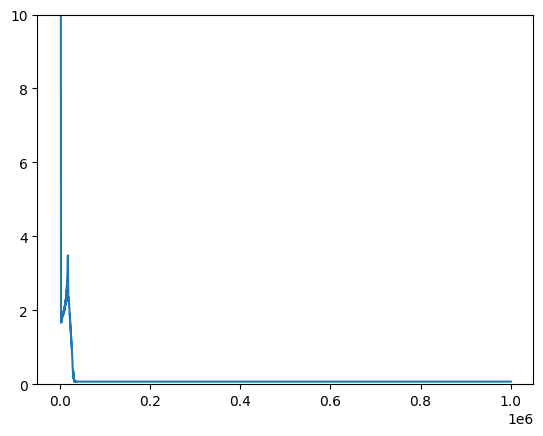

In [6]:
def gradient_descent_RMS(X, gamma=0.99, epsilon = 0.00000001, step_size=0.0001, stop_cond=0.01, max_iterations=1000000):
    iterations = 0
    gradient_norm = []
    s = np.array([1, 1])
    for _ in range(max_iterations):
        iterations += 1
        grad = func_gradient(X)
        norm_grad = np.linalg.norm(grad)
        gradient_norm.append(norm_grad)
        if norm_grad < stop_cond:
            return [X, iterations, gradient_norm]
        s = gamma * s + (1 - gamma) * np.square(grad)
        X = X - step_size * (grad / (np.sqrt(s + epsilon)))
    return [X, iterations, gradient_norm]

grad_desc_RMS_vals = gradient_descent_RMS(init_x)
all_gradient_norms.append([grad_desc_RMS_vals[2], grad_desc_RMS_vals[1]])
print("Gradient Descent (Momentum) Final Value:", grad_desc_RMS_vals[0], "over", grad_desc_RMS_vals[1], "iterations.")
plt.plot([i for i in range(grad_desc_RMS_vals[1])], grad_desc_RMS_vals[2])
plt.ylim(top=10, bottom=0)
plt.show()

Gradient Descent (Momentum) Final Value: [0.98914197 0.97835493] over 33625 iterations.


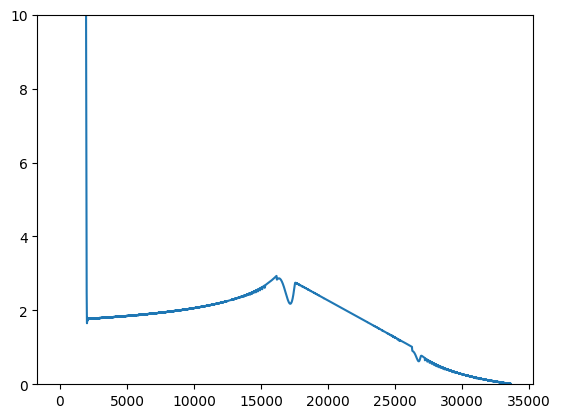

In [7]:
def gradient_descent_adam(X, beta=0.9, gamma=0.9, epsilon = 0.00000001, step_size=0.0001, stop_cond=0.01, max_iterations=1000000):
    iterations = 0
    gradient_norm = []
    s = np.array([1, 1])
    v = np.array([0, 0])
    for _ in range(max_iterations):
        iterations += 1
        grad = func_gradient(X)
        norm_grad = np.linalg.norm(grad)
        gradient_norm.append(norm_grad)
        if norm_grad < stop_cond:
            return [X, iterations, gradient_norm]
        v = beta * v + (1 - beta) * grad
        s = gamma * s + (1 - gamma) * np.square(grad)
        X = X - step_size * (v / (np.sqrt(s + epsilon)))
    return [X, iterations, gradient_norm]

grad_desc_adam_vals = gradient_descent_adam(init_x)
all_gradient_norms.append([grad_desc_adam_vals[2], grad_desc_adam_vals[1]])
print("Gradient Descent (Momentum) Final Value:", grad_desc_adam_vals[0], "over", grad_desc_adam_vals[1], "iterations.")
plt.plot([i for i in range(grad_desc_adam_vals[1])], grad_desc_adam_vals[2])
plt.ylim(top=10, bottom=0)
plt.show()

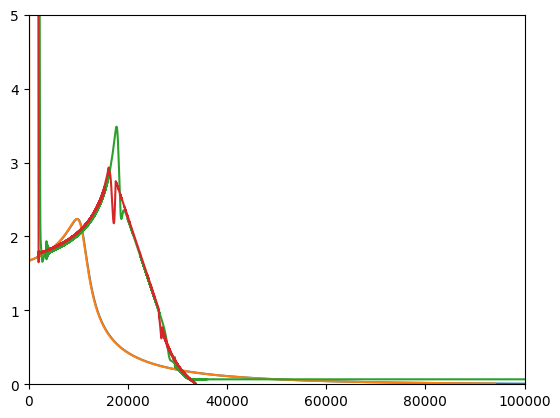

In [8]:
for g_n in all_gradient_norms:
    plt.plot([i for i in range(g_n[1])], g_n[0])
plt.ylim(top=5, bottom=0)
plt.xlim(left=0, right=100000)
plt.show()

**Problem 2**

Gradient Descent (Momentum) Final Value: [-1.11254273 -2.16147584  4.67932159] over 727 iterations.


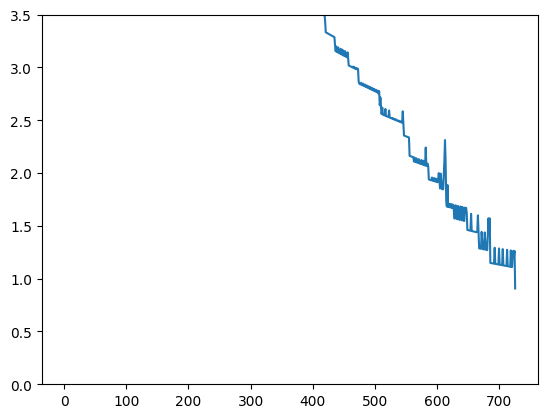

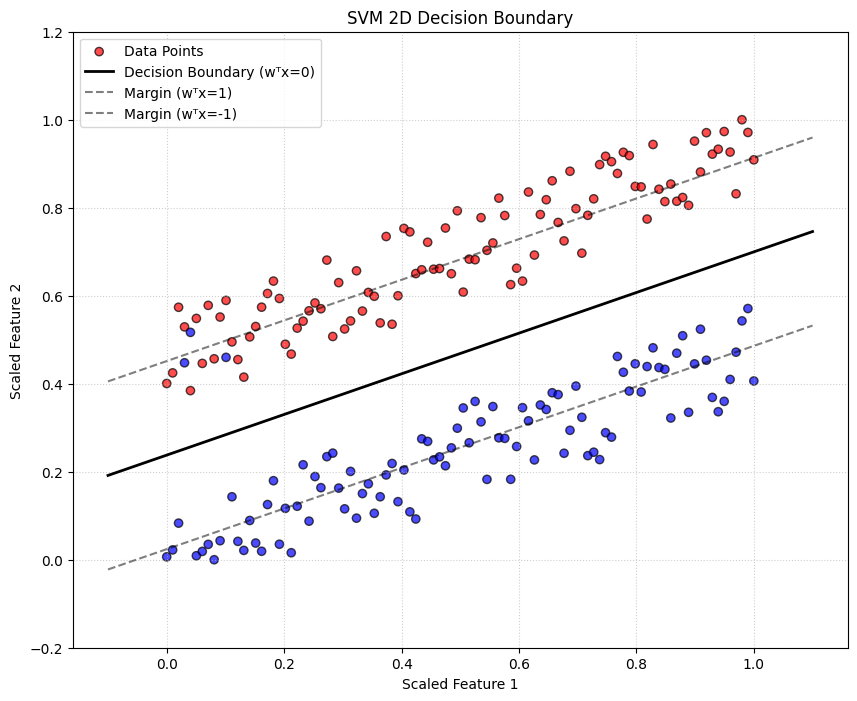

In [ ]:
r2_data = np.loadtxt('DataSetR2.txt', delimiter=" ")
X, y = (r2_data[:, 0:2], r2_data[:, 2])
X_min = np.min(X, axis=0)
X_max = np.max(X, axis=0)

X = (X - X_min) / (X_max - X_min)

X = np.hstack((np.ones((X.shape[0], 1)), X))

def loss_function(w, X, y, lambda_=1):
    return (1 / 2) * (np.linalg.norm(w) ** 2) + (lambda_ / X.shape[0]) * (np.sum(np.maximum(0, 1 - y * (X@w))))

# print(loss_function(np.array([100, 100, 100]), X, y))

def loss_function_subgradient(w, X, y, lambda_=1):
    non_zero_values = ((1 - y * (X@w)) > 0)
    return w + (lambda_ / X.shape[0]) * (-np.sum(y[non_zero_values].reshape(-1, 1) * X[non_zero_values], axis=0))
# print(loss_function_subgradient(np.array([100, 100, 100]), X, y))

def svm_subgradient_descent(w, X, y, lambda_=1, step_size=0.001, stop_cond=0.001, max_iterations=5000000):
    iterations = 0
    subgradient_norm = []
    for _ in range(max_iterations):
        iterations += 1
        subgrad = loss_function_subgradient(w, X, y, lambda_)
        subgrad_norm = np.linalg.norm(subgrad)
        subgradient_norm.append(subgrad_norm)
        w_new = w - step_size * subgrad
        if subgrad_norm < stop_cond:
            return (w, iterations, subgradient_norm)
        elif np.linalg.norm(w_new - w) < stop_cond:
            return (w, iterations, subgradient_norm)
        w = w_new
    return (w, iterations, subgradient_norm)

subgradient_val = svm_subgradient_descent(np.array([1, 1, 1]), X, y, lambda_=100)
print("Gradient Descent (Momentum) Final Value:", subgradient_val[0], "over", subgradient_val[1], "iterations.")
plt.plot([i for i in range(subgradient_val[1])], subgradient_val[2])
plt.ylim(top=3.5, bottom=0)
plt.show()

bias = subgradient_val[0][0]
w1 = subgradient_val[0][1]
w2 = subgradient_val[0][2]

plt.figure(figsize=(10, 8))

plt.scatter(X[:, 1], X[:, 2], c=y, cmap='bwr', alpha=0.7, edgecolors='k', label='Data Points')

x1_range = np.linspace(X[:, 1].min() - 0.1, X[:, 1].max() + 0.1, 100)
x2_boundary = -(w1 * x1_range + bias) / w2

x2_margin_plus = -(w1 * x1_range + bias - 1) / w2
x2_margin_minus = -(w1 * x1_range + bias + 1) / w2

plt.plot(x1_range, x2_boundary, 'k-', linewidth=2, label='Decision Boundary (wᵀx=0)')
plt.plot(x1_range, x2_margin_plus, 'k--', alpha=0.5, label='Margin (wᵀx=1)')
plt.plot(x1_range, x2_margin_minus, 'k--', alpha=0.5, label='Margin (wᵀx=-1)')

plt.title(f'SVM 2D Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.ylim(X[:, 2].min() - 0.2, X[:, 2].max() + 0.2)

plt.show()